In [30]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import openpyxl

In [31]:
data = pd.read_excel('data.xlsx')

# X real e Y real
X_r = data['x']
Y_r = data['y']

In [32]:
def derivadas():
    a = np.sum((X_r - np.mean(X_r)) * (Y_r - np.mean(Y_r))) / np.sum((X_r - np.mean(X_r)) ** 2)
    b = np.mean(Y_r) - a * np.mean(X_r)
    return a, b

In [33]:
def calcula_erro(a,b):   
  erro = 0

  # Pareamento de x e y e fazendo for nos dois arrays ao mesmo tempo
  for x_r, y_r in zip(X_r, Y_r):
  # Previsão
   y_p =  a*x_r + b
  # Soma das distâncias
   erro += (y_r - y_p) ** 2
  return erro

In [34]:
# Criando dois arrays com comprimento 100
N = 100
A = np.linspace(-10, 10, N)
B = np.linspace(-10, 10, N)

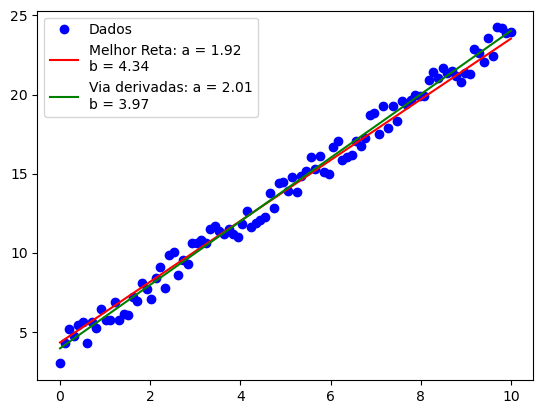

<Figure size 640x480 with 0 Axes>

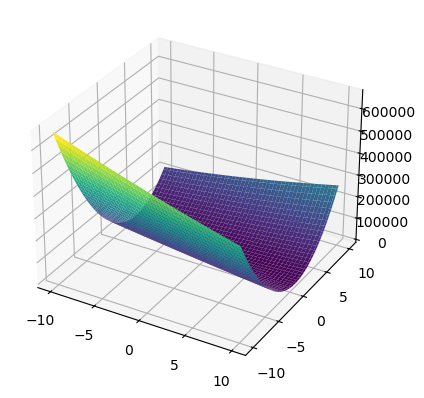

In [ ]:
erros = np.zeros(shape = (N,N))

menor_erro = calcula_erro(A[0],B[0])
melhor_a = A[0]
melhor_b = B[0]

for i,a in enumerate(A):
    for j, b in enumerate(B):
        erro = calcula_erro(a,b)
        erros[i][j] = erro
        if erro < menor_erro:
            menor_erro = erro
            melhor_a = a
            melhor_b = b

a,b = derivadas()

melhor_reta = melhor_a * X_r + melhor_b

plt.plot(X_r,Y_r,'bo',label = 'Dados')
plt.plot(X_r,melhor_reta,'r',label = f'Melhor Reta: a = {melhor_a:.2f}\nb = {melhor_b:.2f}')
plt.plot(X_r, a*X_r + b,'g',label = f'Via derivadas: a = {a:.2f}\nb = {b:.2f}')
plt.legend()
plt.figure()
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
X, Y = np.meshgrid(A, B)

ax.plot_surface(X, Y, erros, cmap='viridis')
plt.show()